In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
DATA_DIR = '/content/drive/My Drive/Datathon_VinTelligence/data/datathon-2026-round-1'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.figsize': (16, 6),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})


In [4]:
df_sales = pd.read_csv(f'{DATA_DIR}/sales.csv', parse_dates=['Date'])
df_web   = pd.read_csv(f'{DATA_DIR}/web_traffic.csv', parse_dates=['date'])
df_promo = pd.read_csv(f'{DATA_DIR}/promotions.csv', parse_dates=['start_date', 'end_date'])
df_orders = pd.read_csv(f'{DATA_DIR}/orders.csv', parse_dates=['order_date'])
df_items  = pd.read_csv(f'{DATA_DIR}/order_items.csv')
df_returns = pd.read_csv(f'{DATA_DIR}/returns.csv', parse_dates=['return_date'])
datasets = {
    'Sales': df_sales, 'Web Traffic': df_web, 'Promotions': df_promo,
    'Orders': df_orders, 'Order Items': df_items, 'Returns': df_returns
}
summary_rows = []
for name, df in datasets.items():
    summary_rows.append({
        'Dataset': name,
        'Rows': f"{len(df):,}",
        'Columns': df.shape[1],
        'Missing (%)': f"{df.isnull().mean().mean() * 100:.2f}%",
        'Duplicates': df.duplicated().sum()
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.set_caption("📋 Dataset Overview"))
full_range = pd.date_range(df_sales['Date'].min(), df_sales['Date'].max(), freq='D')
missing_dates = full_range.difference(df_sales['Date'])
dup_dates = df_sales[df_sales['Date'].duplicated(keep=False)]


,Dataset,Rows,Columns,Missing (%),Duplicates
0,Sales,"3,833",3,0.00%,0
1,Web Traffic,"3,652",7,0.00%,0
2,Promotions,50,10,8.00%,0
3,Orders,"646,945",8,0.00%,0
4,Order Items,"714,669",7,23.04%,0
5,Returns,"39,939",7,0.00%,0


In [5]:
neg_rev = (df_sales['Revenue'] <= 0).sum()
neg_cogs = (df_sales['COGS'] <= 0).sum()
df_sales['Gross_Margin'] = (df_sales['Revenue'] - df_sales['COGS']) / df_sales['Revenue']
anomalous_margin = df_sales[(df_sales['Gross_Margin'] < 0) | (df_sales['Gross_Margin'] > 0.95)]

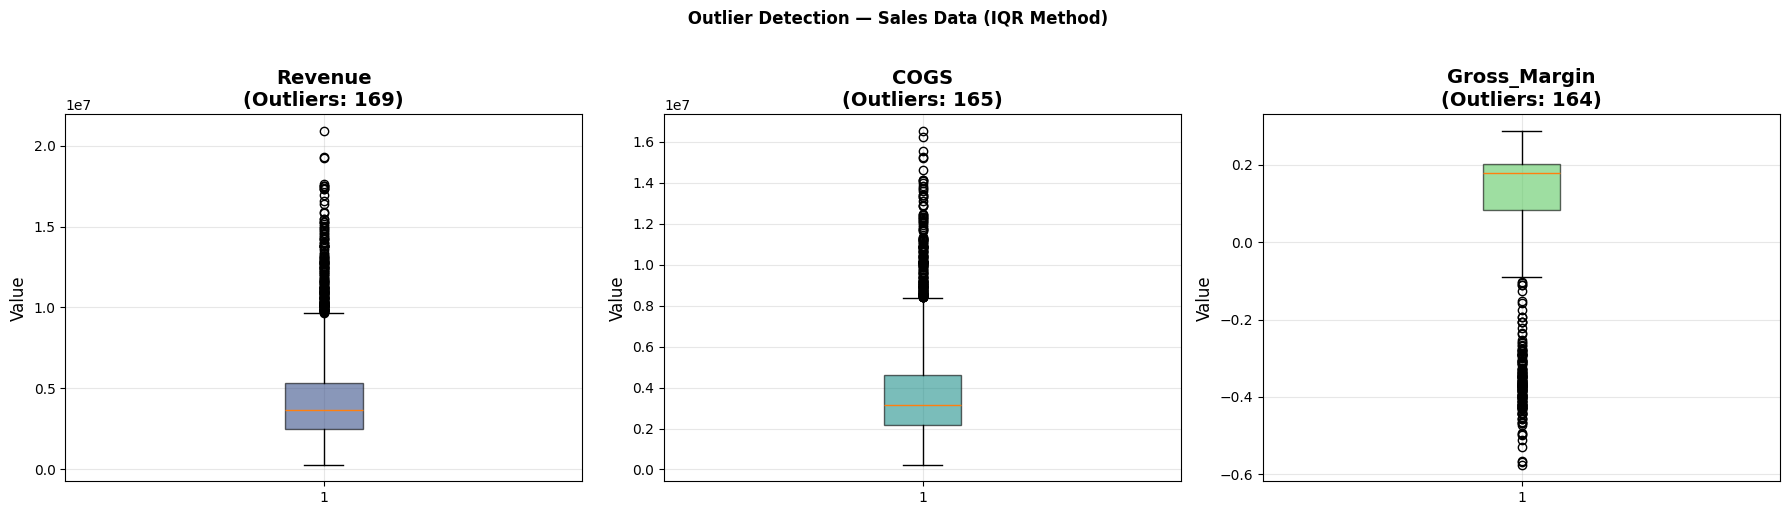

In [9]:
palette = sns.color_palette('viridis', n_colors=3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(['Revenue', 'COGS', 'Gross_Margin']):
    data = df_sales[col]
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    axes[idx].boxplot(data, vert=True, patch_artist=True,
                      boxprops=dict(facecolor=palette[idx], alpha=0.6))
    axes[idx].set_title(f'{col}\n(Outliers: {len(outliers)})')
    axes[idx].set_ylabel('Value')
plt.suptitle(' Outlier Detection — Sales Data (IQR Method)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
df = df_sales[['Date', 'Revenue', 'COGS']].copy()
df = df.sort_values('Date').reset_index(drop=True)
wt_agg = df_web.groupby('date').agg(
    total_sessions=('sessions', 'sum'),
    total_page_views=('page_views', 'sum'),
    total_visitors=('unique_visitors', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration=('avg_session_duration_sec', 'mean'),
    n_traffic_sources=('traffic_source', 'nunique'),  # diversity of traffic
).reset_index().rename(columns={'date': 'Date'})
wt_source = df_web.pivot_table(
    index='date', columns='traffic_source', values='sessions',
    aggfunc='sum', fill_value=0
).reset_index().rename(columns={'date': 'Date'})
wt_source.columns = ['Date'] + [f'src_{c}_sessions' for c in wt_source.columns[1:]]
wt_agg = pd.merge(wt_agg, wt_source, on='Date', how='left')
df = pd.merge(df, wt_agg, on='Date', how='left')
print("\n🏷️  Merging promotion features...")
date_range = df['Date']
promo_count = []
promo_discount_avg = []
promo_discount_max = []
promo_has_stackable = []
for d in date_range:
    active = df_promo[(df_promo['start_date'] <= d) & (df_promo['end_date'] >= d)]
    promo_count.append(len(active))
    promo_discount_avg.append(active['discount_value'].mean() if len(active) > 0 else 0)
    promo_discount_max.append(active['discount_value'].max() if len(active) > 0 else 0)
    promo_has_stackable.append(int(active['stackable_flag'].sum() > 0) if len(active) > 0 else 0)



🏷️  Merging promotion features...


In [11]:
df['active_promos_count'] = promo_count
df['avg_promo_discount'] = promo_discount_avg
df['max_promo_discount'] = promo_discount_max
df['has_stackable_promo'] = promo_has_stackable
orders_daily = df_orders.groupby('order_date').agg(
    total_orders=('order_id', 'count'),
    cancelled_orders=('order_status', lambda x: (x == 'cancelled').sum()),
    returned_orders=('order_status', lambda x: (x == 'returned').sum()),
).reset_index().rename(columns={'order_date': 'Date'})
orders_daily['cancellation_rate'] = orders_daily['cancelled_orders'] / orders_daily['total_orders']
device_daily = df_orders.groupby('order_date')['device_type'].apply(
    lambda x: (x == 'mobile').mean()
).reset_index().rename(columns={'order_date': 'Date', 'device_type': 'mobile_ratio'})
df = pd.merge(df, orders_daily, on='Date', how='left')
df = pd.merge(df, device_daily, on='Date', how='left')
oi_merged = pd.merge(
    df_orders[['order_id', 'order_date']],
    df_items[['order_id', 'discount_amount', 'unit_price', 'quantity']],
    on='order_id'
)
oi_daily = oi_merged.groupby('order_date').agg(
    total_discount_amount=('discount_amount', 'sum'),
    avg_order_value=('unit_price', lambda x: (x * oi_merged.loc[x.index, 'quantity']).sum() / max(1, len(x.index))),
).reset_index().rename(columns={'order_date': 'Date'})
df = pd.merge(df, oi_daily, on='Date', how='left')
returns_daily = df_returns.groupby('return_date').agg(
    total_returns=('return_id', 'count'),
    total_refund=('refund_amount', 'sum'),
).reset_index().rename(columns={'return_date': 'Date'})
df = pd.merge(df, returns_daily, on='Date', how='left')

In [12]:
missing_report = df.isnull().sum()
missing_report = missing_report[missing_report > 0].sort_values(ascending=False)
web_fill_cols = [c for c in df.columns if c.startswith('total_') or c.startswith('src_') or c.startswith('avg_')]
for col in web_fill_cols:
    if col in ['avg_bounce_rate', 'avg_session_duration']:
        df[col] = df[col].fillna(df[col].median())  # median for rates
    elif col in ['avg_order_value', 'avg_promo_discount']:
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna(0)
order_fill_cols = ['total_orders', 'cancelled_orders', 'returned_orders',
                   'total_discount_amount', 'total_returns', 'total_refund']
for col in order_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
rate_fill_cols = ['cancellation_rate', 'mobile_ratio', 'n_traffic_sources']
for col in rate_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['dayofyear'] = df['Date'].dt.dayofyear
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['Date'].dt.quarter
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

calendar_cols = ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear',
                 'quarter', 'is_weekend', 'is_month_start', 'is_month_end',
                 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


In [13]:
lag_targets = ['Revenue', 'COGS']  # KHÔNG dùng total_orders
lag_periods = [1, 7, 14, 30]      # GIỮ lag — đây là features mạnh nhất

for col in lag_targets:
    for lag in lag_periods:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    for w in [7, 14, 30]:
        df[f'{col}_roll_mean_{w}'] = df[col].shift(1).rolling(window=w, min_periods=1).mean()
        df[f'{col}_roll_std_{w}'] = df[col].shift(1).rolling(window=w, min_periods=1).std()

df['revenue_momentum_7_30'] = (df['Revenue_roll_mean_7'] / df['Revenue_roll_mean_30'].replace(0, np.nan)).fillna(1)
df['cogs_momentum_7_30'] = (df['COGS_roll_mean_7'] / df['COGS_roll_mean_30'].replace(0, np.nan)).fillna(1)
df['gross_margin_lag_1'] = ((df['Revenue'] - df['COGS']) / df['Revenue']).shift(1)
df['gross_margin_lag_7'] = ((df['Revenue'] - df['COGS']) / df['Revenue']).shift(7)

# Drop rows thiếu lag history (30 ngày đầu)
n_before = len(df)
# Fixed typo: changed `c in lag_periods` to `c in lag_targets`
lag_check = [f'{c}_lag_{l}' for c in lag_targets for l in lag_periods]
df = df.dropna(subset=lag_check).reset_index(drop=True).fillna(0)
n_after = len(df)
print(f"Dropped {n_before - n_after} rows → Remaining: {n_after}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

Dropped 30 rows → Remaining: 3803
Date range: 2012-08-03 → 2022-12-31



   Revenue:
     Original — Skewness: 1.675, Kurtosis: 4.038
     Log1p    — Skewness: -0.154

   COGS:
     Original — Skewness: 1.626, Kurtosis: 3.679
     Log1p    — Skewness: -0.163


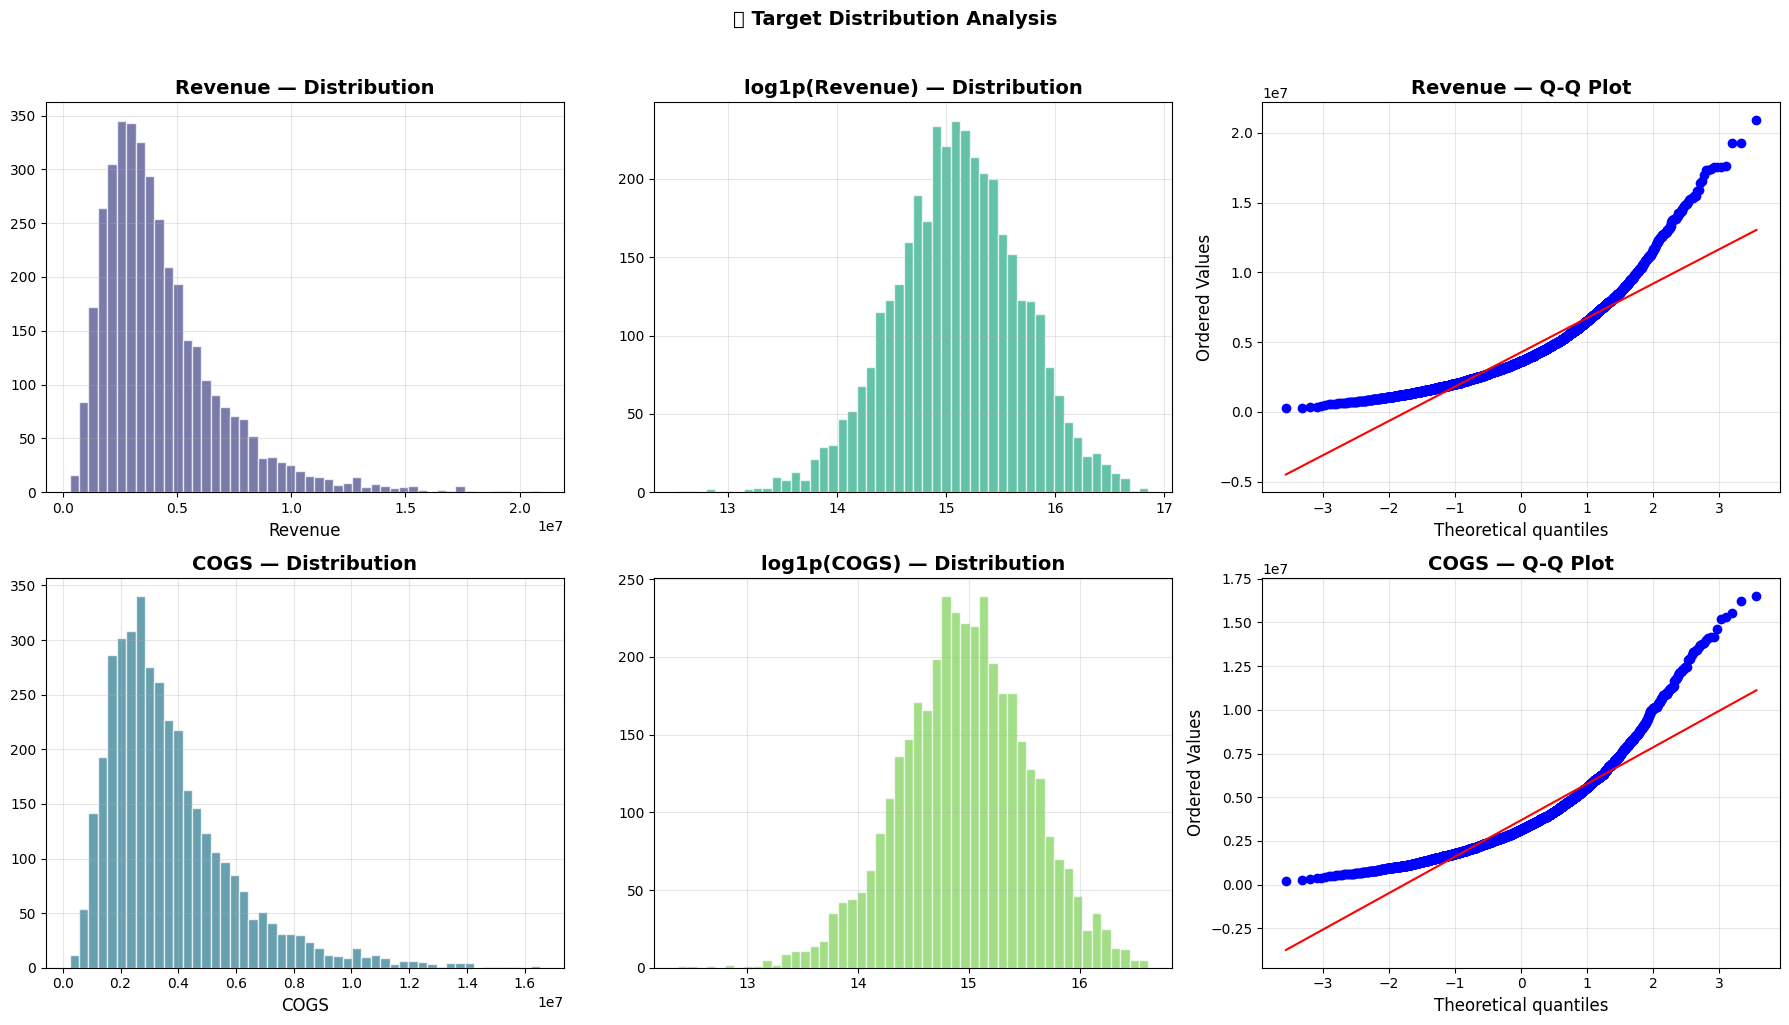

🔗 STEP 9: FEATURE CORRELATION ANALYSIS

🔝 Top 15 features correlated with Revenue:
    1. total_orders                        r = +0.9358  ████████████████████████████
    2. cancelled_orders                    r = +0.8795  ██████████████████████████
    3. Revenue_lag_1                       r = +0.8657  █████████████████████████
    4. returned_orders                     r = +0.8376  █████████████████████████
    5. COGS_lag_1                          r = +0.8368  █████████████████████████
    6. Revenue_roll_mean_7                 r = +0.6956  ████████████████████
    7. Revenue_roll_mean_30                r = +0.6833  ████████████████████
    8. Revenue_roll_mean_14                r = +0.6705  ████████████████████
    9. COGS_roll_mean_30                   r = +0.6632  ███████████████████
   10. COGS_roll_mean_7                    r = +0.6589  ███████████████████
   11. Revenue_lag_30                      r = +0.6523  ███████████████████
   12. COGS_lag_30                         r

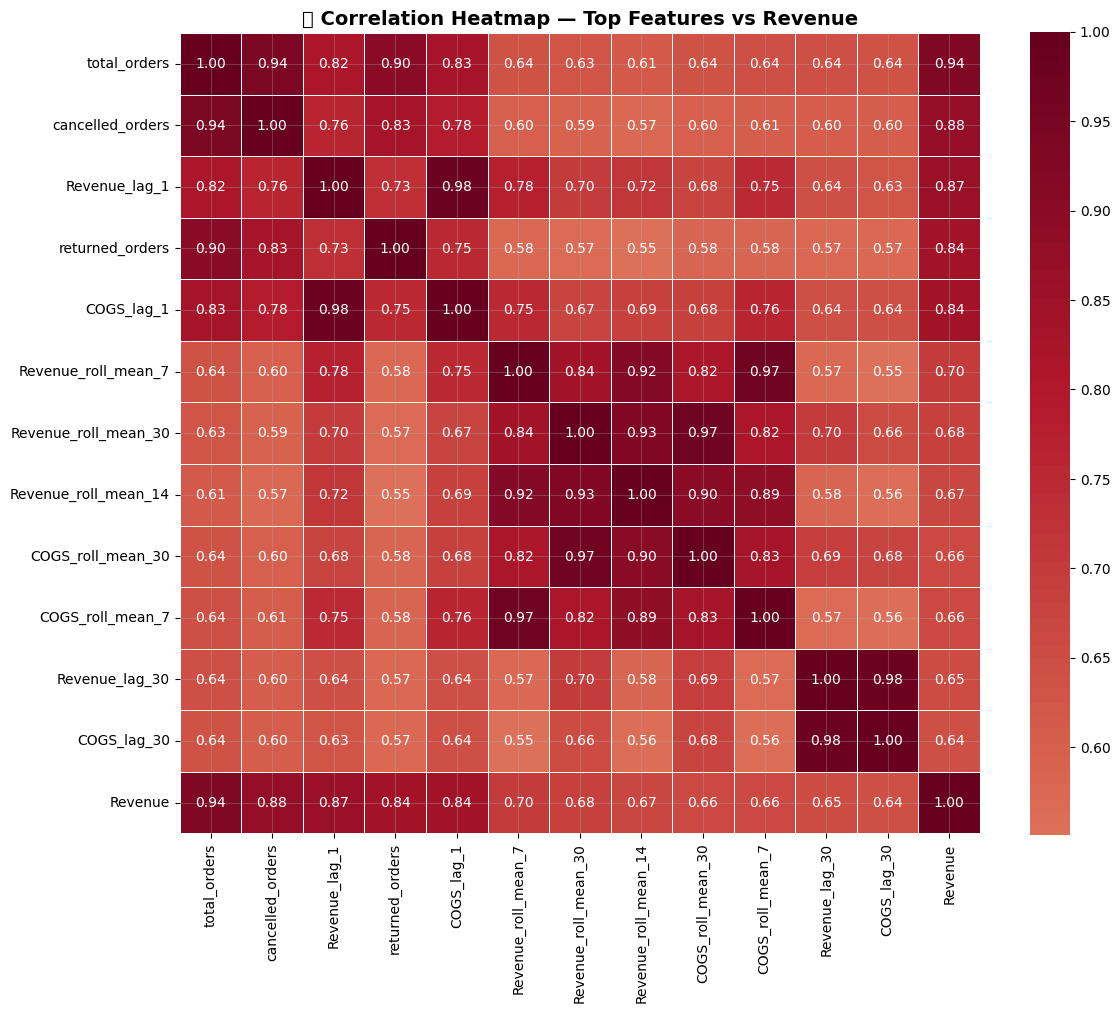


⚠️  Dropping 16 features with >0.95 correlation:
     total_sessions ↔ total_visitors  (r=0.994)
     avg_promo_discount ↔ max_promo_discount  (r=0.993)
     month ↔ dayofyear  (r=0.997)
     month ↔ weekofyear  (r=0.970)
     dayofyear ↔ weekofyear  (r=0.972)
     month ↔ quarter  (r=0.972)
     dayofyear ↔ quarter  (r=0.969)
     Revenue_lag_1 ↔ COGS_lag_1  (r=0.976)
     Revenue_lag_7 ↔ COGS_lag_7  (r=0.976)
     Revenue_lag_14 ↔ COGS_lag_14  (r=0.976)

💾 Cleaned data saved to: Datathon_VinTelligence/models/cleaned_forecasting_data.csv


In [16]:
palette = sns.color_palette('viridis', n_colors=4)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, target in enumerate(['Revenue', 'COGS']):
    axes[row, 0].hist(df[target], bins=50, color=palette[row], alpha=0.7, edgecolor='white')
    axes[row, 0].set_title(f'{target} — Distribution')
    axes[row, 0].set_xlabel(target)
    log_vals = np.log1p(df[target])
    axes[row, 1].hist(log_vals, bins=50, color=palette[row + 2], alpha=0.7, edgecolor='white')
    axes[row, 1].set_title(f'log1p({target}) — Distribution')
    stats.probplot(df[target], dist="norm", plot=axes[row, 2])
    axes[row, 2].set_title(f'{target} — Q-Q Plot')
    skew = df[target].skew()
    kurt = df[target].kurtosis()
    log_skew = log_vals.skew()
    print(f"\n   {target}:")
    print(f"     Original — Skewness: {skew:.3f}, Kurtosis: {kurt:.3f}")
    print(f"     Log1p    — Skewness: {log_skew:.3f}")

plt.suptitle('📊 Target Distribution Analysis', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("=" * 70)
print("🔗 STEP 9: FEATURE CORRELATION ANALYSIS")
print("=" * 70)

exclude_meta = ['Date', 'COGS', 'Gross_Margin']
feature_cols = [c for c in df.columns if c not in exclude_meta and c != 'Revenue']
corr_with_rev = df[feature_cols + ['Revenue']].corr()['Revenue'].drop('Revenue').sort_values(ascending=False)

print("\n🔝 Top 15 features correlated with Revenue:")
for i, (feat, corr) in enumerate(corr_with_rev.head(15).items(), 1):
    bar = '█' * int(abs(corr) * 30)
    print(f"   {i:2d}. {feat:35s} r = {corr:+.4f}  {bar}")

print("\n🔻 Bottom 5 features (least correlated):")
for feat, corr in corr_with_rev.tail(5).items():
    print(f"       {feat:35s} r = {corr:+.4f}")

top_feats = list(corr_with_rev.head(12).index) + ['Revenue']
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[top_feats].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('🔗 Correlation Heatmap — Top Features vs Revenue', fontweight='bold')
plt.tight_layout()
plt.show()


# Define feature groups
target_cols = ['Revenue', 'COGS']
meta_cols = ['Date', 'Gross_Margin']

# All remaining columns are features
feature_cols_final = [c for c in df.columns if c not in target_cols + meta_cols]

# Remove highly correlated redundant features (multicollinearity > 0.95)
corr_matrix = df[feature_cols_final].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []
to_drop = set()
for col in upper_tri.columns:
    for idx in upper_tri.index:
        if upper_tri.loc[idx, col] > 0.95:
            high_corr_pairs.append((idx, col, upper_tri.loc[idx, col]))
            to_drop.add(col)  # drop the second one

if to_drop:
    print(f"\n⚠️  Dropping {len(to_drop)} features with >0.95 correlation:")
    for pair in high_corr_pairs[:10]:
        print(f"     {pair[0]} ↔ {pair[1]}  (r={pair[2]:.3f})")
    feature_cols_final = [c for c in feature_cols_final if c not in to_drop]

X = df[feature_cols_final]
y_revenue = df['Revenue']
y_cogs = df['COGS']
output_path = f'{DATA_DIR}/cleaned_forecasting_data.csv'
df.to_csv(output_path, index=False)
print(f"\n💾 Cleaned data saved to: {output_path}")

In [17]:
!pip install xgboost -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print(f'✅ X shape: {X.shape}')
print(f'✅ y_revenue: {y_revenue.shape}, y_cogs: {y_cogs.shape}')
print(f'✅ Features: {len(feature_cols_final)}')


✅ X shape: (3803, 47)
✅ y_revenue: (3803,), y_cogs: (3803,)
✅ Features: 47


In [18]:
tscv = TimeSeriesSplit(n_splits=5)
models = {
    'XGBoost': XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=500, max_depth=15,
        min_samples_split=5, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
}

scoring = {
    'R2': make_scorer(r2_score),
    'MSE': make_scorer(mean_squared_error, greater_is_better=False)
}
all_results = {}
all_cv_details = {}

for target_name, y_target in [('Revenue', y_revenue), ('COGS', y_cogs)]:
    print(f'\n{"="*70}')
    print(f'🎯 TARGET: {target_name}')
    print(f'{"="*70}')

    results = {}
    cv_details = {}

    for name, model in models.items():
        print(f'\n  🔄 Training {name}...')
        cv = cross_validate(
            model, X, y_target,
            cv=tscv, scoring=scoring,
            return_train_score=True
        )

        r2_scores = cv['test_R2']
        mse_scores = -cv['test_MSE']

        results[name] = {
            'R2_mean': r2_scores.mean(),
            'R2_std': r2_scores.std(),
            'MSE_mean': mse_scores.mean(),
            'MSE_std': mse_scores.std(),
            'RMSE_mean': np.sqrt(mse_scores).mean()
        }
        cv_details[name] = {'R2': r2_scores, 'MSE': mse_scores}

        print(f'    ✅ R² = {r2_scores.mean():.6f} (±{r2_scores.std():.6f})')
        print(f'    ✅ RMSE = {np.sqrt(mse_scores).mean():,.2f}')

    all_results[target_name] = results
    all_cv_details[target_name] = cv_details



🎯 TARGET: Revenue

  🔄 Training XGBoost...
    ✅ R² = 0.982777 (±0.005097)
    ✅ RMSE = 310,581.52

  🔄 Training RandomForest...
    ✅ R² = 0.979210 (±0.008472)
    ✅ RMSE = 339,938.54

🎯 TARGET: COGS

  🔄 Training XGBoost...
    ✅ R² = 0.970592 (±0.008716)
    ✅ RMSE = 334,995.50

  🔄 Training RandomForest...
    ✅ R² = 0.958593 (±0.013949)
    ✅ RMSE = 385,535.52


In [19]:

for target_name in ['Revenue', 'COGS']:
    results = all_results[target_name]
    cv_details = all_cv_details[target_name]
    print(f'\n{"="*70}')
    print(f'📊 KẾT QUẢ: {target_name}')
    print(f'{"="*70}')
    # Bảng tổng hợp
    results_df = pd.DataFrame(results).T
    results_df.columns = ['R² (Mean)', 'R² (Std)', 'MSE (Mean)', 'MSE (Std)', 'RMSE (Mean)']
    results_df.index.name = 'Model'
    display(results_df.style.format({
        'R² (Mean)': '{:.6f}', 'R² (Std)': '{:.6f}',
        'MSE (Mean)': '{:,.2f}', 'MSE (Std)': '{:,.2f}',
        'RMSE (Mean)': '{:,.2f}'
    }).set_caption(f'Model Comparison — {target_name} Forecasting'))

    for name in models:
        print(f'\n  --- {name} ---')
        fold_df = pd.DataFrame({
            'Fold': [f'Fold {i+1}' for i in range(5)],
            'R²': cv_details[name]['R2'],
            'MSE': cv_details[name]['MSE'],
            'RMSE': np.sqrt(cv_details[name]['MSE'])
        })
        display(fold_df.style.format({'R²': '{:.6f}', 'MSE': '{:,.2f}', 'RMSE': '{:,.2f}'}))

    best = max(results, key=lambda k: results[k]['R2_mean'])
    print(f'\n  Best for {target_name}: {best} (R²={results[best]["R2_mean"]:.6f})')



📊 KẾT QUẢ: Revenue


,R² (Mean),R² (Std),MSE (Mean),MSE (Std),RMSE (Mean)
Model,,,,,
XGBoost,0.982777,0.005097,"110,246,156,118.66","75,342,971,893.17","310,581.52"
RandomForest,0.979210,0.008472,"134,217,548,699.02","93,903,620,169.25","339,938.54"



  --- XGBoost ---


,Fold,R²,MSE,RMSE
0,Fold 1,0.976632,"156,427,893,569.27","395,509.66"
1,Fold 2,0.976776,"229,453,665,677.35","479,013.22"
2,Fold 3,0.986801,"99,096,373,486.59","314,795.76"
3,Fold 4,0.984977,"36,320,952,134.56","190,580.57"
4,Fold 5,0.988700,"29,931,895,725.51","173,008.37"



  --- RandomForest ---


...


  --- XGBoost ---


,Fold,R²,MSE,RMSE
0,Fold 1,0.970859,"137,803,725,888.72","371,219.24"
1,Fold 2,0.958676,"291,379,637,781.54","539,795.92"
2,Fold 3,0.984643,"77,806,968,307.87","278,939.00"
3,Fold 4,0.973715,"50,371,139,505.95","224,435.16"
4,Fold 5,0.965065,"67,906,195,600.10","260,588.17"



  --- RandomForest ---


,Fold,R²,MSE,RMSE
0,Fold 1,0.967291,"154,676,150,239.86","393,288.89"
1,Fold 2,0.952574,"334,402,207,470.01","578,275.20"
2,Fold 3,0.980766,"97,450,908,039.85","312,171.28"
3,Fold 4,0.951668,"92,618,712,116.89","304,333.23"
4,Fold 5,0.940665,"115,334,276,326.09","339,609.01"



  Best for COGS: XGBoost (R²=0.970592)


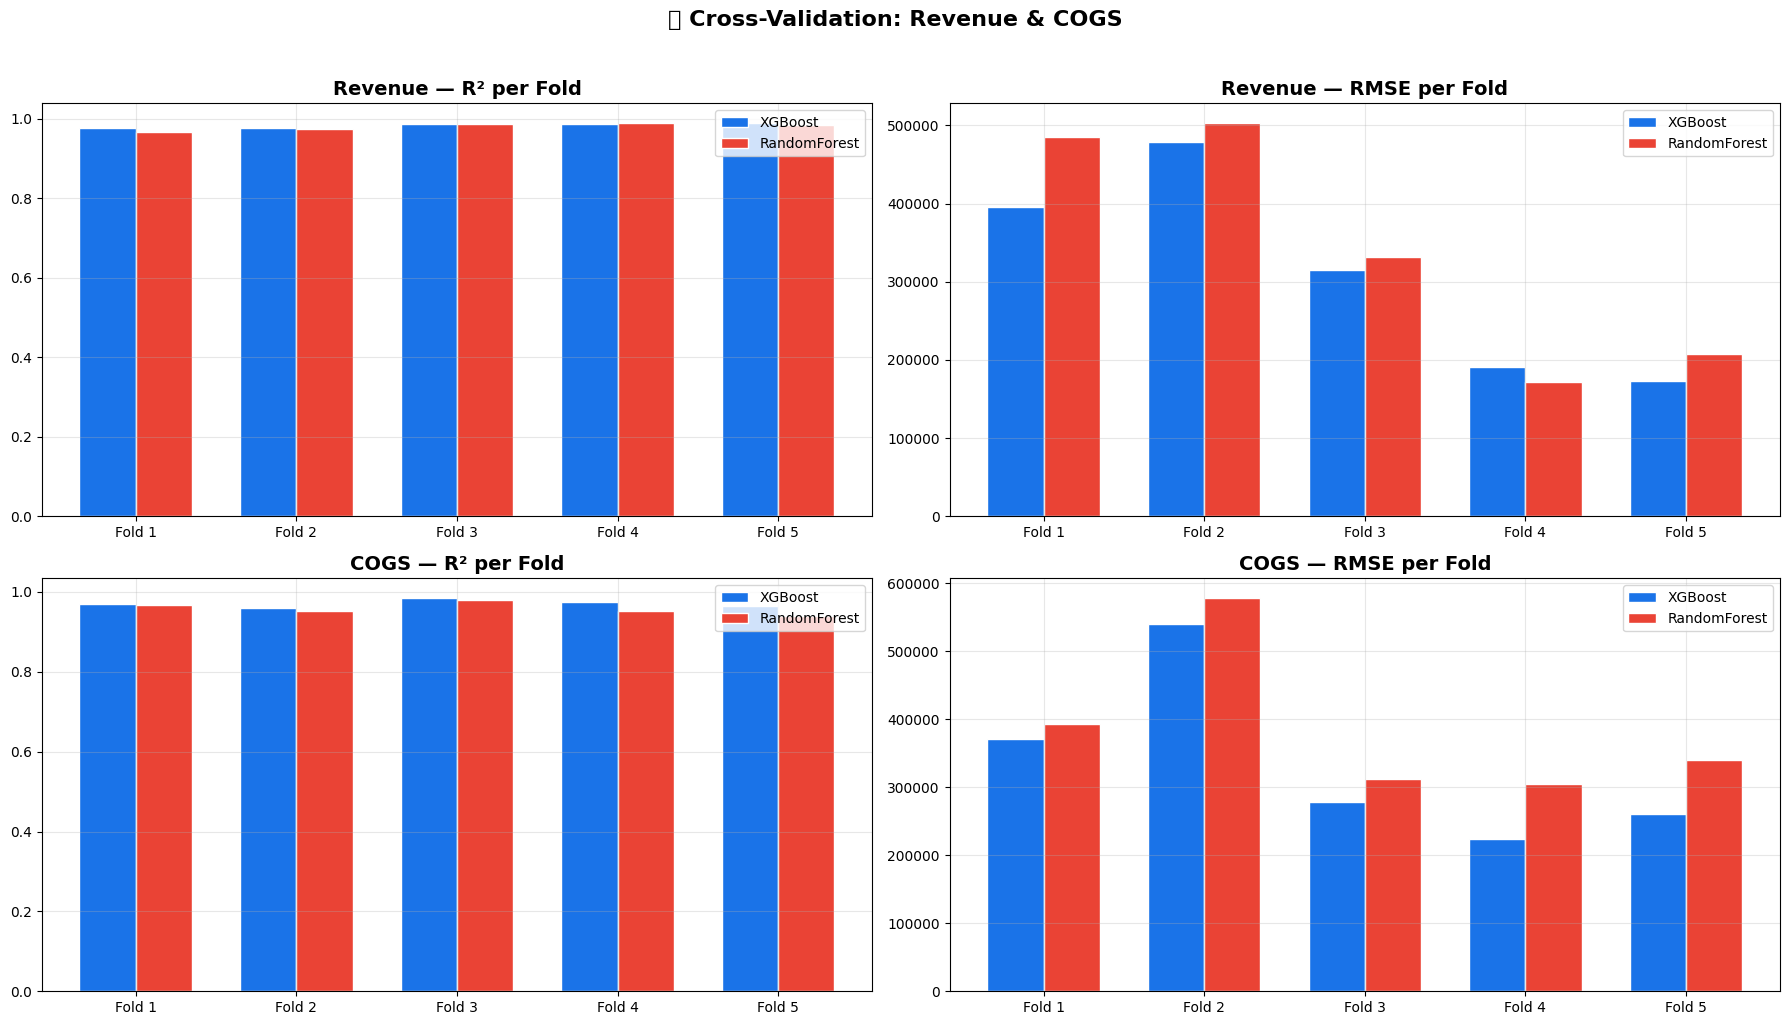

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fold_labels = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.35
for row, target_name in enumerate(['Revenue', 'COGS']):
    cv_details = all_cv_details[target_name]

    axes[row, 0].bar(x - width/2, cv_details['XGBoost']['R2'], width,
                     label='XGBoost', color='#1A73E8', edgecolor='white')
    axes[row, 0].bar(x + width/2, cv_details['RandomForest']['R2'], width,
                     label='RandomForest', color='#EA4335', edgecolor='white')
    axes[row, 0].set_title(f'{target_name} — R² per Fold', fontweight='bold')
    axes[row, 0].set_xticks(x); axes[row, 0].set_xticklabels(fold_labels)
    axes[row, 0].legend(); axes[row, 0].grid(axis='y', alpha=0.3)

    axes[row, 1].bar(x - width/2, np.sqrt(cv_details['XGBoost']['MSE']), width,
                     label='XGBoost', color='#1A73E8', edgecolor='white')
    axes[row, 1].bar(x + width/2, np.sqrt(cv_details['RandomForest']['MSE']), width,
                     label='RandomForest', color='#EA4335', edgecolor='white')
    axes[row, 1].set_title(f'{target_name} — RMSE per Fold', fontweight='bold')
    axes[row, 1].set_xticks(x); axes[row, 1].set_xticklabels(fold_labels)
    axes[row, 1].legend(); axes[row, 1].grid(axis='y', alpha=0.3)

plt.suptitle('📊 Cross-Validation: Revenue & COGS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


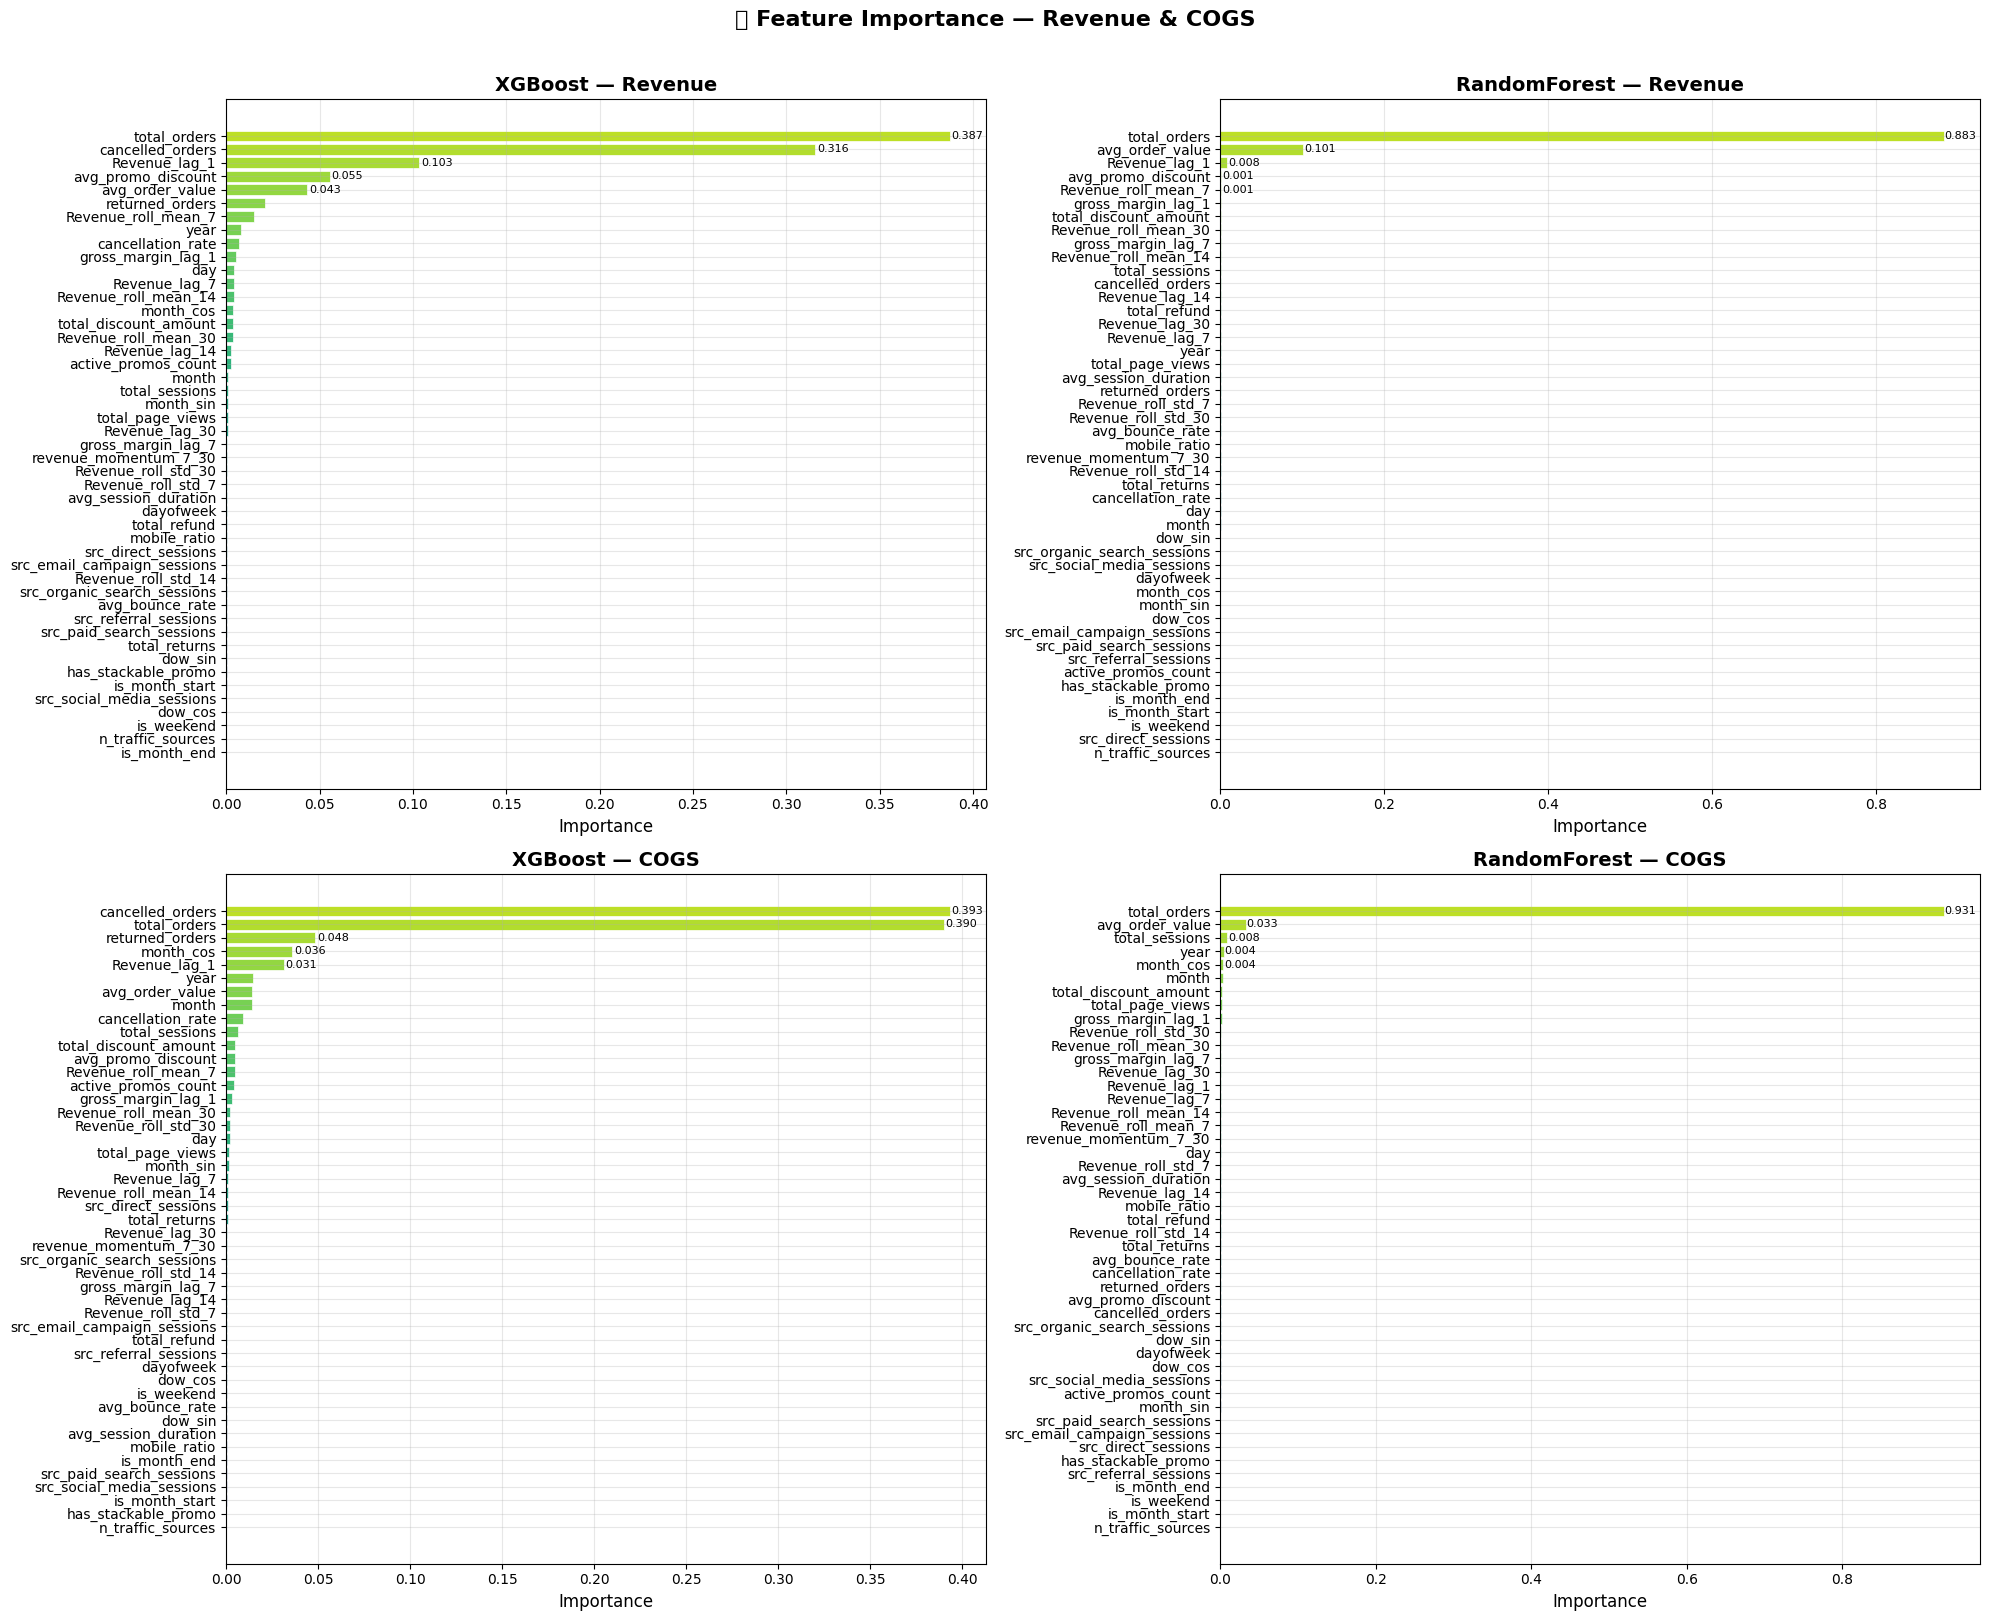



🔝 Top 5 — XGBoost (Revenue):
  1. total_orders                        → 0.3875
  2. cancelled_orders                    → 0.3156
  3. Revenue_lag_1                       → 0.1033
  4. avg_promo_discount                  → 0.0555
  5. avg_order_value                     → 0.0435

🔝 Top 5 — RandomForest (Revenue):
  1. total_orders                        → 0.8829
  2. avg_order_value                     → 0.1007
  3. Revenue_lag_1                       → 0.0084
  4. avg_promo_discount                  → 0.0006
  5. Revenue_roll_mean_7                 → 0.0006


🔝 Top 5 — XGBoost (COGS):
  1. cancelled_orders                    → 0.3931
  2. total_orders                        → 0.3899
  3. returned_orders                     → 0.0482
  4. month_cos                           → 0.0358
  5. Revenue_lag_1                       → 0.0313

🔝 Top 5 — RandomForest (COGS):
  1. total_orders                        → 0.9308
  2. avg_order_value                     → 0.0329
  3. total_sessions     

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
for row, (target_name, y_target) in enumerate([('Revenue', y_revenue), ('COGS', y_cogs)]):
    for col_idx, (name, model) in enumerate(models.items()):
        model.fit(X, y_target)
        importances = model.feature_importances_
        feat_imp = pd.DataFrame({
            'Feature': feature_cols_final,
            'Importance': importances
        }).sort_values('Importance', ascending=True)

        colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp)))
        axes[row, col_idx].barh(feat_imp['Feature'], feat_imp['Importance'],
                                color=colors, edgecolor='white', linewidth=0.5)
        axes[row, col_idx].set_xlabel('Importance')
        axes[row, col_idx].set_title(f'{name} — {target_name}', fontweight='bold')
        axes[row, col_idx].grid(axis='x', alpha=0.3)

        # Annotate top 5
        for _, r in feat_imp.tail(5).iterrows():
            axes[row, col_idx].text(r['Importance'] + 0.001, r['Feature'],
                                  f"{r['Importance']:.3f}", va='center', fontsize=8)
plt.suptitle('🔝 Feature Importance — Revenue & COGS', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5
for target_name, y_target in [('Revenue', y_revenue), ('COGS', y_cogs)]:
    print(f'\n{"="*60}')
    for name, model in models.items():
        model.fit(X, y_target)
        feat_imp = pd.DataFrame({
            'Feature': feature_cols_final,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False).head(5)
        print(f'\n🔝 Top 5 — {name} ({target_name}):')
        for i, (_, r) in enumerate(feat_imp.iterrows(), 1):
            print(f"  {i}. {r['Feature']:35s} → {r['Importance']:.4f}")


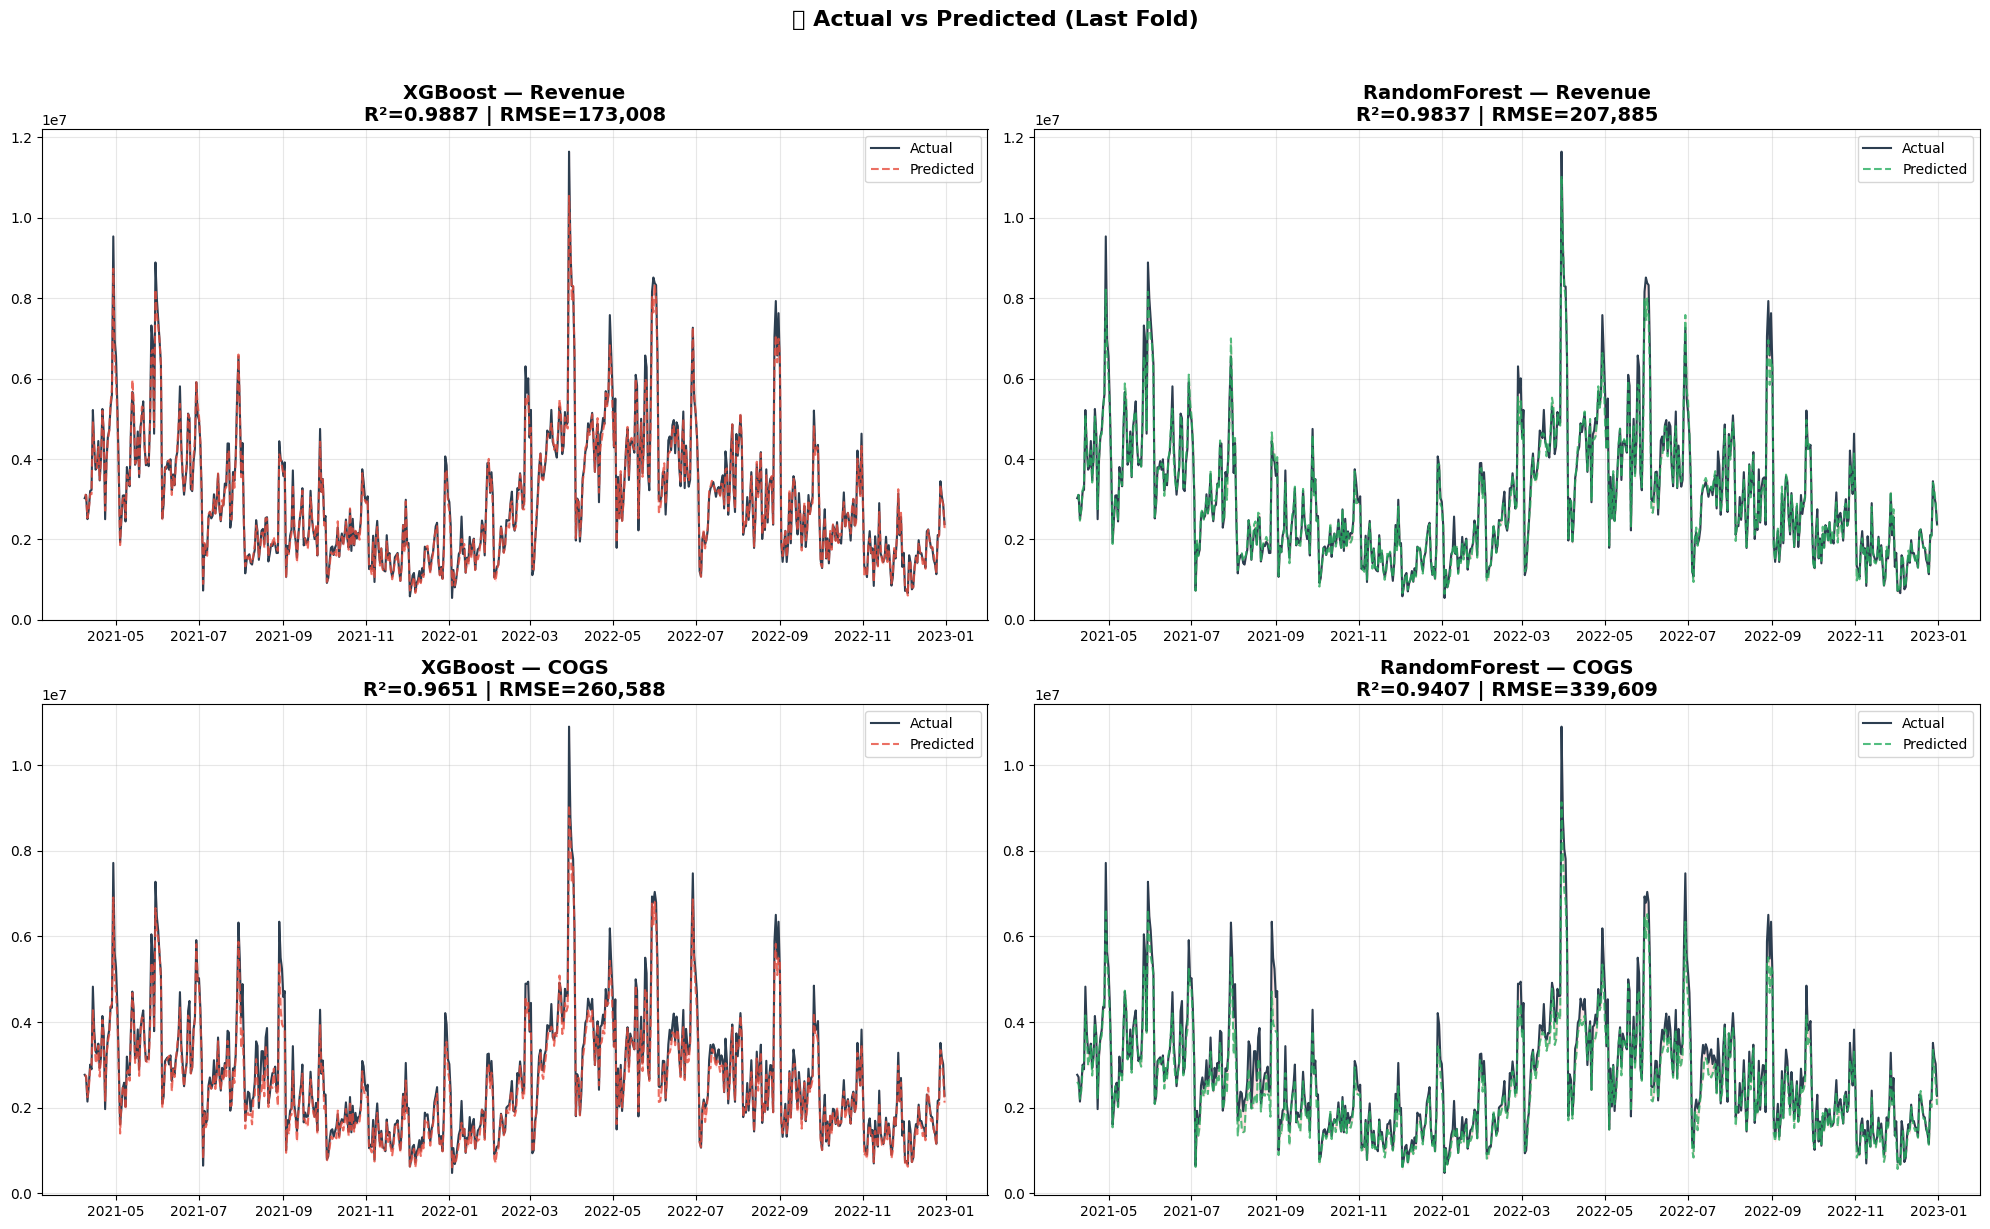

In [22]:

for train_idx, test_idx in tscv.split(X):
    pass
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
dates_test = df['Date'].iloc[test_idx]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
colors_pred = ['#E74C3C', '#27AE60']
for row, (target_name, y_target) in enumerate([('Revenue', y_revenue), ('COGS', y_cogs)]):
    y_train, y_test = y_target.iloc[train_idx], y_target.iloc[test_idx]

    for col_idx, (name, model) in enumerate(models.items()):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        axes[row, col_idx].plot(dates_test, y_test.values, label='Actual',
                                color='#2C3E50', linewidth=1.5)
        axes[row, col_idx].plot(dates_test, y_pred, label='Predicted',
                                color=colors_pred[col_idx], linewidth=1.5,
                                linestyle='--', alpha=0.8)
        axes[row, col_idx].fill_between(dates_test, y_test.values, y_pred,
                                        alpha=0.1, color='red')
        axes[row, col_idx].set_title(
            f'{name} — {target_name}\nR²={r2:.4f} | RMSE={rmse:,.0f}',
            fontweight='bold')
        axes[row, col_idx].legend()
        axes[row, col_idx].grid(alpha=0.3)

plt.suptitle('📈 Actual vs Predicted (Last Fold)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
import joblib
import os

DATA_DIR = '/content/drive/MyDrive/Datathon_VinTelligence'
MODELS_DIR = os.path.join(DATA_DIR, 'models')

# Tạo thư mục nếu chưa có (nếu đã có nó sẽ bỏ qua)
os.makedirs(MODELS_DIR, exist_ok=True)

model_filename = 'model_v1.pkl'
full_model_path = os.path.join(MODELS_DIR, model_filename)
joblib.dump(models, full_model_path)

print(f"Đã lưu model vào: {full_model_path}")

Đã lưu model vào: /content/drive/MyDrive/Datathon_VinTelligence/models/model_v1.pkl
